# AI-Based Voltage Estimation Tutorial | <font color=red>Part 2</font>: Keras-Based LV Voltage Estimation with Reference Voltage — Version 2.0


## 1. Introduction


### Objectives

The objectives of this tutorial are:

1. To familiarise yourself with how a varying upstream **medium-voltage (MV) supply** affects customer voltages in a low-voltage (LV) distribution network. In Part 1, the upstream supply was fixed. Here, similar active power **P** and reactive power **Q** values can occur with different customer voltages. All power and voltage data are **simulated**, not measurements from real customers.

2. To become familiar with using **reference voltages (Vref)** as extra inputs to a **Keras** neural network. You will prepare the data, train models with and without Vref, and check their estimates for the same customers. This tutorial is intended for **electrical engineering students in the Power specialization** who have completed Part 1; **no additional neural-network background is required**. New concepts are explained when they are needed.


### Structure of this Notebook

The rest of this notebook is divided into three parts:

- **2. Tutorial.**
    - You will learn, step by step, how to prepare simulated data and train Keras models with and without reference-voltage inputs.
    - You will learn how to compare shared model settings and check voltage estimates and errors on separate test data.
- **3. Exercises.** You will first prepare two input sets and compare their validation errors, then train and test your selected voltage estimators.
- **4. Exercise Workspace.** Use the relevant tutorial code to complete each numbered task and display its results.

<font color='red'>**<u>Note</u>:**</font> Work through **2. Tutorial** before attempting the exercises. Make sure you understand which data are used to train the model, which are used to choose its settings, and which are reserved for the final check.


## 2. Tutorial

Follow the sections in order. Each step introduces the relevant code, the settings you can change and the output to inspect. Start with the **quick** training mode in Section 2.5.1.


### 2.1 Test LV Circuit and Considerations

The simulated LV feeder supplies **31 single-phase customers**. Its topology is shown in **Figure 1**. Two supplied datasets describe the feeder with a fixed or a varying upstream MV supply voltage.

- All P, Q and V values are **simulation outputs**. This notebook loads prepared data; it does not run a new power-flow simulation.
- At each time step, all 31 customers' P/Q values are used to estimate customer voltage magnitudes **at that same time**, not at a future time. The second model also receives three reference voltages.
- Each row represents 5 minutes. P/Q columns are ordered `P1, Q1, ..., P31, Q31`; voltage-file columns are ordered `V1, ..., V31`.
- The fixed-upstream data are used to inspect the MV effect. **Both models are trained on the varying-upstream data**. Test data are kept for the final check. The topology provides context and phase labels but is not a neural-network input.


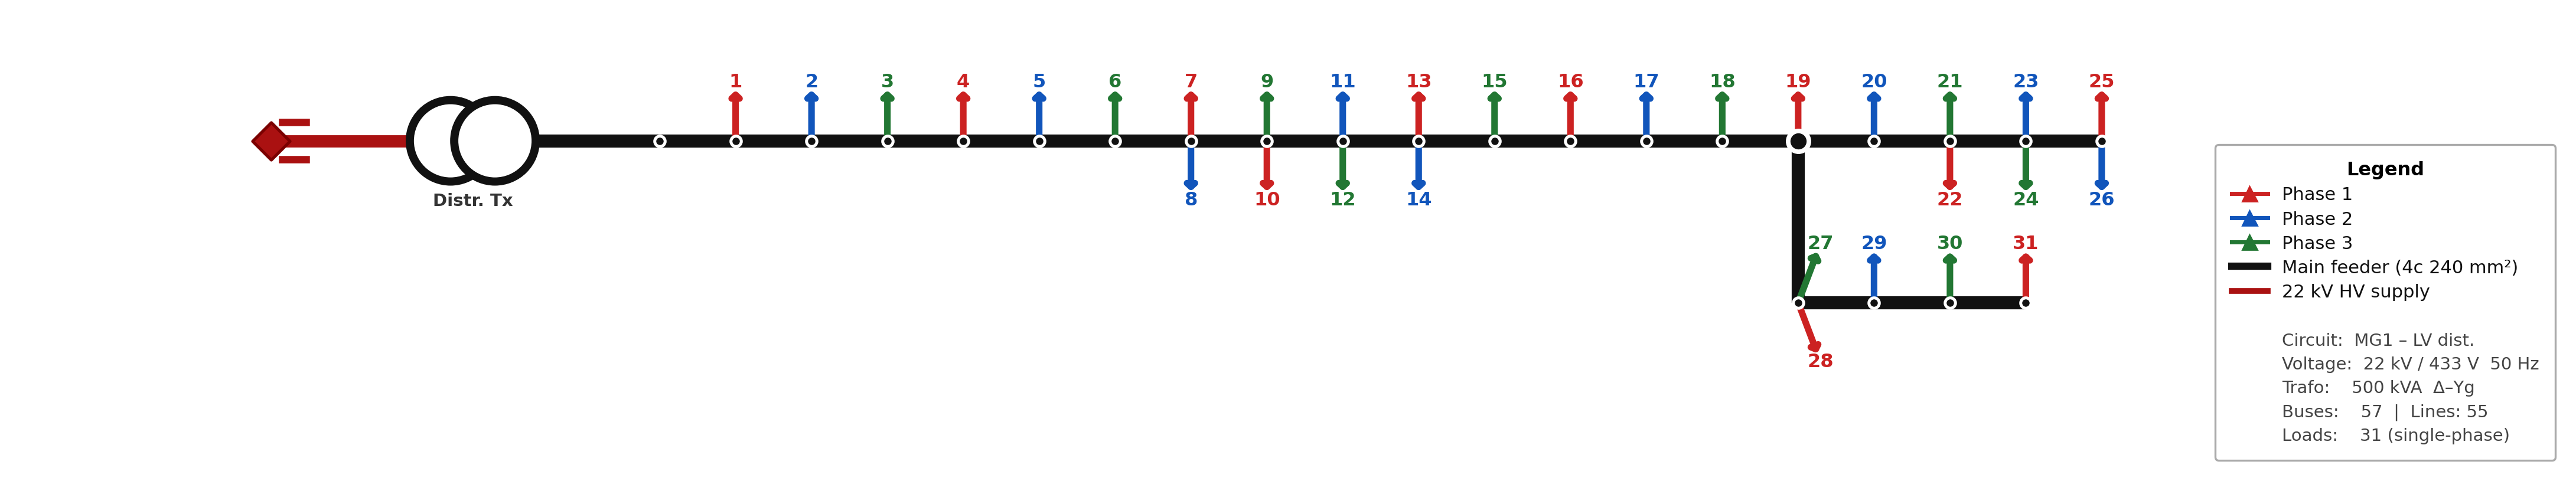


**<center>Figure 1. Simulated LV Circuit Topology</center>**


| Item | Value in the supplied dataset |
|---|---|
| Customers | 31 |
| Inputs per time step | 62 P/Q values; 65 values when Vref is added |
| Outputs per time step | 28 voltage magnitudes, excluding the reference customers |
| Sampling interval | 5 minutes |
| Training data | 6,048 rows (21 days) |
| Test data | 2,016 rows (7 days) |

<p align="center"><strong>Table 1. Data used for LV voltage estimation</strong></p>

The model comparison uses the following inputs and targets:

| Model | Inputs for one time step | Outputs for that time step |
|---|---|---|
| P/Q only | 62 P/Q values from C1–C31 | 28 voltages at C4–C31 |
| P/Q + Vref | The same 62 P/Q values + voltages at C1–C3 | The same 28 voltages at C4–C31 |

<p align="center"><strong>Table 2. Inputs and outputs of the two models</strong></p>

C1, C2 and C3 supply one reference voltage from each phase. Their simulated voltages represent inputs assumed available when making a prediction; they are **not** prediction targets. A practical deployment would need sensors providing these reference voltages at the prediction time.

The hidden-layer settings and training budget are shared. Adding Vref adds three input connections per hidden neuron, so the two models do not have identical parameter counts. Results apply to these simulated conditions. Accuracy on a different feeder or on real measurements would require a separate assessment.


### 2.2 Initialisation

Run the cells below in order. This notebook works both locally and in Google Colab.


#### 2.2.1 Import libraries

Start with **Prepare the runtime**, then run the import cell. **Keras** builds the neural network and **TensorFlow** performs its calculations. In Colab, the first cell installs the libraries; if a restart is requested, restart and run from that cell again.


In [1]:
#@title Prepare the runtime (run this cell)
import os
import sys
import subprocess
from pathlib import Path
import itertools
import time
import zipfile
import json

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG") or os.getenv("COLAB_BACKEND_VERSION"))
if IN_COLAB:
    # Install the runtime libraries only; Jupyter itself is already provided.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "tensorflow>=2.16,<3", "keras>=3,<4", "numpy>=1.26",
        "pandas>=2.2", "scikit-learn>=1.4", "matplotlib>=3.8",
    ])

os.environ["KERAS_BACKEND"] = "tensorflow"  # Set before importing Keras.


In [2]:
import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)
print("Environment:", "Google Colab" if IN_COLAB else "Local Jupyter")


Environment: Local Jupyter


The following cell prepares the tutorial files.

- **Local:** Locally, keep Tutorial 1 and Tutorial 2 as neighbouring folders and start in this tutorial folder or the project root. Tutorial 2 reads the LV data from Tutorial 1; you do not need to run Tutorial 1 first.
- **Colab:** use the upload button shown by this cell to select `Tutorial_2_Keras_v2_0_colab_data.zip`. Do not rename or unpack it yourself. This ZIP already includes both LV and MV datasets; no separate Tutorial 1 upload is needed.

<font color=red>Note:</font> Only use the supplied ZIP from a trusted source. A new Colab runtime requires another upload.


In [3]:
# Prepare the local working path or upload the Colab data package.
added_path = ""
if (Path.cwd() / "Tutorial_2_MV_Effects_Reference_Voltage").is_dir():
    added_path = "Tutorial_2_MV_Effects_Reference_Voltage"

if IN_COLAB:
    from google.colab import files

    added_path = "Tutorial_2_Keras_v2_0"
    data_directory = Path.cwd() / added_path
    data_directory.mkdir(parents=True, exist_ok=True)
    archive_path = data_directory / "Tutorial_2_Keras_v2_0_colab_data.zip"
    if not archive_path.is_file():
        files.upload(target_dir=str(data_directory))
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(data_directory)


#### 2.2.2 Set the working path

Run the following code to set and display the folder containing the tutorial files. The default works locally and in Colab. If you start Jupyter elsewhere, set `TUTORIAL_DIRECTORY = Path("your/tutorial/folder")` here. Individual data paths can be changed in Section 2.3.1.


In [4]:
TUTORIAL_DIRECTORY = Path.cwd() / added_path
print(f"The files are located in: {TUTORIAL_DIRECTORY}")


The files are located in: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_2_MV_Effects_Reference_Voltage


#### 2.2.3 Set the random seed

The model starts with randomly chosen weights. A **random seed** helps repeat the same starting point and training-row order. The code sets the seed and reports the software versions and devices; results can still vary across environments.

The same seed does not give identical weights to networks with different input sizes.


In [4]:
SEED = 42

def set_seed(seed=SEED):
    keras.utils.set_random_seed(seed)

set_seed()
print(f"Keras: {keras.__version__}; TensorFlow: {tf.__version__}")
print(f"Keras backend: {keras.backend.backend()}")
print("Available devices:", tf.config.list_physical_devices())
print(f"Initial comparison seed: {SEED}")


Keras: 3.15.1; TensorFlow: 2.21.0
Keras backend: tensorflow


Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Initial comparison seed: 42


### 2.3 Simulated Data Preparation

Here, **inputs** are the P/Q values, with or without Vref, supplied to the model. **Targets** are the corresponding simulated voltages it should learn to estimate. Load both upstream scenarios, check their structure and inspect the **training period**.


#### 2.3.1 Set the individual data file paths

`LV_DATA_FOLDER` and `MV_DATA_FOLDER` select the supplied data locations. The eight entries in `DATA_FILES` are the paths you can edit; **each may point to a different folder**.

- **Locally:** LV data are read from `Tutorial_1_LV_Vol_Estimation/synthentic_data_5_min_LV`; MV data are read from `synthetic_data_5_min_MV` directly inside this Tutorial 2 folder. Keep both tutorial folders together under the project folder when using these defaults. No local `data` folder is needed in Tutorial 2.
- **In Colab:** both datasets come from the supplied ZIP, under `data/synthetic_data_5_min_LV` and `data/synthetic_data_5_min_MV`. No separate Tutorial 1 upload is needed.

| Entry | Contents | Use |
|---|---|---|
| `PQ_lv_tr` | Fixed-upstream training P/Q | Check that the scenarios have nearly matching power profiles |
| `V_lv_tr` | Fixed-upstream training voltages | Compare with varying-upstream training voltages |
| `PQ_lv_te` | Fixed-upstream test P/Q | File-consistency check only |
| `V_lv_te` | Fixed-upstream test voltages | File-structure check only; not used for model evaluation |
| `PQ_mv_tr` | Varying-upstream training P/Q | Training and model selection inputs |
| `V_mv_tr` | Varying-upstream training voltages | Reference inputs at C1–C3; targets at C4–C31 |
| `PQ_mv_te` | Varying-upstream test P/Q | Final-check inputs |
| `V_mv_te` | Varying-upstream test voltages | Final-check reference inputs at C1–C3; targets at C4–C31 |

`lv` means **fixed upstream** and `mv` means **varying upstream**. Both datasets describe customer quantities on the LV feeder, not voltages on MV buses. `tr` and `te` mean training and test.

The loop checks one file at a time and prints its full path. All values are **simulated**. Each entry accepts a relative or absolute path. In Colab, use uploaded files rather than paths on your computer.


In [6]:
# Select the data folders for local Jupyter or Colab.
if IN_COLAB:
    # Colab uses both datasets included in the supplied ZIP.
    LV_DATA_FOLDER = TUTORIAL_DIRECTORY / "data/synthetic_data_5_min_LV"
    MV_DATA_FOLDER = TUTORIAL_DIRECTORY / "data/synthetic_data_5_min_MV"
else:
    # Locally, reuse the LV data from Tutorial 1 and the MV data in Tutorial 2.
    LV_DATA_FOLDER = TUTORIAL_DIRECTORY.parent / "Tutorial_1_LV_Vol_Estimation/synthentic_data_5_min_LV"
    MV_DATA_FOLDER = TUTORIAL_DIRECTORY / "synthetic_data_5_min_MV"

# Edit individual entries here if your files are in different folders.
DATA_FILES = {
    "PQ_lv_tr": LV_DATA_FOLDER / "training/PQ.pkl",
    "V_lv_tr": LV_DATA_FOLDER / "training/V.pkl",
    "PQ_lv_te": LV_DATA_FOLDER / "test/PQ.pkl",
    "V_lv_te": LV_DATA_FOLDER / "test/V.pkl",
    "PQ_mv_tr": MV_DATA_FOLDER / "training/PQ.pkl",
    "V_mv_tr": MV_DATA_FOLDER / "training/V.pkl",
    "PQ_mv_te": MV_DATA_FOLDER / "test/PQ.pkl",
    "V_mv_te": MV_DATA_FOLDER / "test/V.pkl",
}

# Check each file before reading any data.
data_files = {}
for name, path in DATA_FILES.items():
    full_path = (TUTORIAL_DIRECTORY / Path(path)).resolve()
    if not full_path.is_file():
        raise FileNotFoundError(f"Cannot find {name}: {full_path}. Update its DATA_FILES entry.")
    data_files[name] = full_path
    print(f"{name}: {full_path}")


PQ_lv_tr: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV\training\PQ.pkl
V_lv_tr: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV\training\V.pkl
PQ_lv_te: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV\test\PQ.pkl
V_lv_te: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV\test\V.pkl
PQ_mv_tr: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_2_MV_Effects_Reference_Voltage\synthetic_data_5_min_MV\training\PQ.pkl
V_mv_tr: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_2_MV_Effects_Reference_Voltage\synthetic_data_5_min_MV\training\V.pkl
PQ_mv_te: C:\Users\18207\Desktop\Capstone_project_2026_sem1-main\Tutorial_2_MV_Effects_Reference_Voltage\synthetic_data_5_min_MV\test\PQ.pkl
V_mv_te: C:\Users\18207\Desktop\Capstone_pr

#### 2.3.2 Import the training and test data

Read each file into a pandas table. `tr` means training, `te` means test, and `df` means DataFrame (a table).

The preview shows only three time steps for the first three customers; **the full data remain loaded**. Test data are kept for the final check, not for choosing model settings.

Load both the fixed- and varying-upstream cases. The preview below uses the varying-upstream training data. Reference inputs and target columns will be separated in Sections 2.3.6–2.3.7.


In [6]:
# Load the fixed-upstream data for comparison and file checks.
PQ_lv_tr_df = pd.read_pickle(data_files["PQ_lv_tr"])
V_lv_tr_df = pd.read_pickle(data_files["V_lv_tr"])
PQ_lv_te_df = pd.read_pickle(data_files["PQ_lv_te"])
V_lv_te_df = pd.read_pickle(data_files["V_lv_te"])
# Load the varying-upstream data used by both neural networks.
PQ_mv_tr_df = pd.read_pickle(data_files["PQ_mv_tr"])
V_mv_tr_df = pd.read_pickle(data_files["V_mv_tr"])
PQ_mv_te_df = pd.read_pickle(data_files["PQ_mv_te"])
V_mv_te_df = pd.read_pickle(data_files["V_mv_te"])

# iloc[row selection, column selection]: preview the first three customers.
print("Varying-upstream training P/Q: first three customers")
display(PQ_mv_tr_df.iloc[:3, :6])
print("Corresponding simulated voltages")
display(V_mv_tr_df.iloc[:3, :3])


Varying-upstream training P/Q: first three customers


,0,1,2,3,4,5
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146


Corresponding simulated voltages


,0,1,2
0,248.504189,248.551056,248.558164
1,248.520249,248.405446,248.463877
2,248.571258,248.412267,248.520852


#### 2.3.3 Check the data and prepare the arrays

Run the four steps below. A `raise` statement stops the code if a required condition is not met.

1. Check that corresponding row and column labels match. P/Q and V must refer to the same time steps and customers; matching labels alone cannot prove that the original data were correctly paired.
2. Convert each table to a numeric `float32` array for Keras. This changes the storage format; **it does not normalise the values**.
3. Check the sizes and reject missing values or infinity.
4. Check that the two scenarios have nearly matching P/Q values before comparing their voltages.

`shape[0]` is the number of rows and `shape[1]` is the number of columns. For each scenario, expect training shapes `(6048, 62)` and `(6048, 31)`, and test shapes `(2016, 62)` and `(2016, 31)`. These are the full voltage arrays; reference inputs and targets have not yet been separated.

The supplied files use numbered rows, not timestamp columns. We retain their supplied time order and use the known five-minute interval. The two scenarios have **nearly matching, not exactly equal**, P/Q values. The check allows a maximum difference of **0.01% of the peak absolute P/Q value in that period**. This is a fixed data-consistency check, not a neural-network setting.


In [7]:
# 1. Check that corresponding row and column labels match.
data_frames = {
    "PQ_lv_tr": PQ_lv_tr_df, "V_lv_tr": V_lv_tr_df,
    "PQ_lv_te": PQ_lv_te_df, "V_lv_te": V_lv_te_df,
    "PQ_mv_tr": PQ_mv_tr_df, "V_mv_tr": V_mv_tr_df,
    "PQ_mv_te": PQ_mv_te_df, "V_mv_te": V_mv_te_df,
}
for name, frame in data_frames.items():
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame.")
    if not frame.index.is_unique or not frame.columns.is_unique:
        raise ValueError(f"{name} has repeated row or column labels.")

for pq_frame, v_frame in [
    (PQ_lv_tr_df, V_lv_tr_df), (PQ_lv_te_df, V_lv_te_df),
    (PQ_mv_tr_df, V_mv_tr_df), (PQ_mv_te_df, V_mv_te_df),
]:
    if not pq_frame.index.equals(v_frame.index):
        raise ValueError("P/Q rows and voltage rows must have the same order.")

for fixed_frame, varying_frame in [
    (PQ_lv_tr_df, PQ_mv_tr_df), (PQ_lv_te_df, PQ_mv_te_df),
    (V_lv_tr_df, V_mv_tr_df), (V_lv_te_df, V_mv_te_df),
]:
    if not fixed_frame.index.equals(varying_frame.index):
        raise ValueError("The upstream scenarios have different row orders.")
    if not fixed_frame.columns.equals(varying_frame.columns):
        raise ValueError("The upstream scenarios have different column orders.")

for train_frame, test_frame in [
    (PQ_lv_tr_df, PQ_lv_te_df), (V_lv_tr_df, V_lv_te_df),
    (PQ_mv_tr_df, PQ_mv_te_df), (V_mv_tr_df, V_mv_te_df),
]:
    if not train_frame.columns.equals(test_frame.columns):
        raise ValueError("Training and test columns must have the same order.")

# 2. Convert each table into a numeric array for Keras.
PQ_lv_tr = PQ_lv_tr_df.to_numpy(dtype=np.float32)
V_lv_tr = V_lv_tr_df.to_numpy(dtype=np.float32)
PQ_lv_te = PQ_lv_te_df.to_numpy(dtype=np.float32)
V_lv_te = V_lv_te_df.to_numpy(dtype=np.float32)
PQ_mv_tr = PQ_mv_tr_df.to_numpy(dtype=np.float32)
V_mv_tr = V_mv_tr_df.to_numpy(dtype=np.float32)
PQ_mv_te = PQ_mv_te_df.to_numpy(dtype=np.float32)
V_mv_te = V_mv_te_df.to_numpy(dtype=np.float32)

# 3. Check expected rows, columns and valid numbers.
arrays = {
    "PQ_lv_tr": PQ_lv_tr, "V_lv_tr": V_lv_tr,
    "PQ_lv_te": PQ_lv_te, "V_lv_te": V_lv_te,
    "PQ_mv_tr": PQ_mv_tr, "V_mv_tr": V_mv_tr,
    "PQ_mv_te": PQ_mv_te, "V_mv_te": V_mv_te,
}
for name, array in arrays.items():
    expected_rows = 6048 if name.endswith("tr") else 2016
    expected_columns = 62 if name.startswith("PQ") else 31
    if array.shape != (expected_rows, expected_columns):
        raise ValueError(f"Unexpected shape for {name}: {array.shape}.")
    if not np.isfinite(array).all():
        raise ValueError(f"{name} contains missing or non-finite values.")

# 4. Check that the power profiles match closely across the two scenarios.
for period, fixed_pq, varying_pq in [
    ("training", PQ_lv_tr, PQ_mv_tr), ("test", PQ_lv_te, PQ_mv_te),
]:
    pq_peak = float(np.abs(fixed_pq).max())
    pq_difference = float(np.abs(fixed_pq - varying_pq).max())
    if pq_difference > max(1e-8, 1e-4 * pq_peak):
        raise ValueError(f"The {period} P/Q scenarios do not match closely enough.")
    print(f"{period.capitalize()} P/Q consistency check passed.")

C = V_mv_tr.shape[1]  # One voltage column per customer: C = 31.
MINUTES_PER_STEP = 5
STEPS_PER_DAY = 24 * 60 // MINUTES_PER_STEP  # 288 time steps per day.
print("Training P/Q and voltage shapes:", PQ_mv_tr.shape, V_mv_tr.shape)
print("Test P/Q and voltage shapes:", PQ_mv_te.shape, V_mv_te.shape)


Training P/Q consistency check passed.
Test P/Q consistency check passed.
Training P/Q and voltage shapes: (6048, 62) (6048, 31)
Test P/Q and voltage shapes: (2016, 62) (2016, 31)


#### 2.3.4 Visualise one day of power and voltage profiles

Choose `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT`. These settings only change the plot, not the training data. Each day contains 288 five-minute time steps.

P/Q columns alternate: `P1, Q1, P2, Q2, ...`. The code draws **P on the first panel, Q on the second, and V on the third**. Customer numbers start at 1; Python column positions start at 0, so customer 1 uses column 0.

These curves show **simulated training data, not model predictions**. Solid lines show the varying-upstream case; dashed lines show the fixed-upstream case. P/Q traces nearly overlap, while voltage traces can separate. P and Q use the supplied data units; voltage is in **V**.


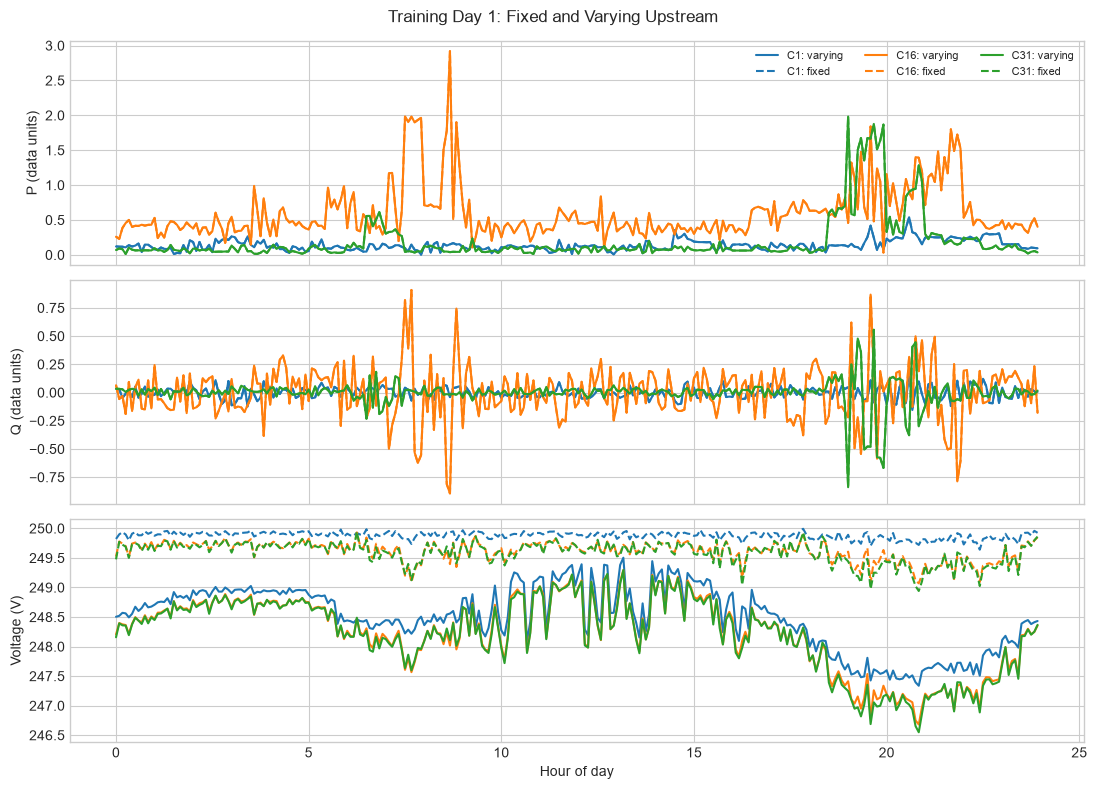

In [8]:
DAY_TO_PLOT = 1
CUSTOMERS_TO_PLOT = [1, 16, 31]

# Check that the chosen day and customers exist.
if not 1 <= DAY_TO_PLOT <= len(V_mv_tr) // STEPS_PER_DAY:
    raise ValueError("Choose an available training day.")
if not CUSTOMERS_TO_PLOT or any(customer not in range(1, C + 1) for customer in CUSTOMERS_TO_PLOT):
    raise ValueError(f"Choose customer numbers from 1 to {C}.")

# Select this day's rows and convert the time axis to hours.
start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60

# Draw one P, Q and V curve per scenario for each selected customer.
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for customer in CUSTOMERS_TO_PLOT:
    index = customer - 1
    colour = f"C{CUSTOMERS_TO_PLOT.index(customer)}"
    axes[0].plot(hours, PQ_mv_tr[start:end, 2 * index], color=colour, label=f"C{customer}: varying")
    axes[0].plot(hours, PQ_lv_tr[start:end, 2 * index], color=colour, linestyle="--", label=f"C{customer}: fixed")
    axes[1].plot(hours, PQ_mv_tr[start:end, 2 * index + 1], color=colour)
    axes[1].plot(hours, PQ_lv_tr[start:end, 2 * index + 1], color=colour, linestyle="--")
    axes[2].plot(hours, V_mv_tr[start:end, index], color=colour)
    axes[2].plot(hours, V_lv_tr[start:end, index], color=colour, linestyle="--")
axes[0].set_ylabel("P (data units)")
axes[1].set_ylabel("Q (data units)")
axes[2].set_ylabel("Voltage (V)")
axes[2].set_xlabel("Hour of day")
axes[0].legend(ncol=3, fontsize=8)
fig.suptitle(f"Training Day {DAY_TO_PLOT}: Fixed and Varying Upstream")
plt.tight_layout()
plt.show()


#### 2.3.5 Inspect MV effects over time and across customers

Calculate **varying-upstream voltage - fixed-upstream voltage** for the training period. With the nearly matching P/Q profiles, this provides an estimate of the upstream MV effect in this controlled simulation. It is not a measured MV-bus voltage, and the small P/Q differences mean it is not an exact isolation of every cause.

The first plot shows the average shift across the feeder during the chosen training day. The second shows each customer's **RMS voltage shift** over all training days. RMS summarises the magnitude of the difference between the two scenarios; it is **not prediction RMSE**. Neither quantity is added to the model inputs.


,Quantity,Training voltage shift (V)
0,Mean,-1.3211
1,Standard deviation,0.5478
2,Minimum,-2.4770
3,Maximum,0.0202


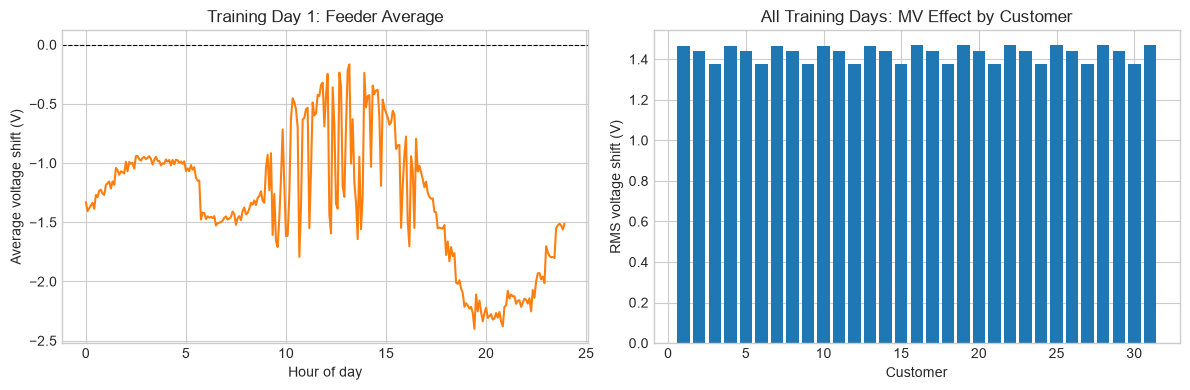

In [9]:
mv_effect_training = V_mv_tr - V_lv_tr
customer_mv_rms = np.sqrt(np.mean(mv_effect_training ** 2, axis=0))
display(pd.DataFrame({
    "Quantity": ["Mean", "Standard deviation", "Minimum", "Maximum"],
    "Training voltage shift (V)": [
        mv_effect_training.mean(), mv_effect_training.std(),
        mv_effect_training.min(), mv_effect_training.max(),
    ],
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hours, mv_effect_training[start:end].mean(axis=1), color="tab:orange")
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Average voltage shift (V)")
axes[0].set_title(f"Training Day {DAY_TO_PLOT}: Feeder Average")
axes[1].bar(np.arange(1, C + 1), customer_mv_rms, color="tab:blue")
axes[1].set_xlabel("Customer")
axes[1].set_ylabel("RMS voltage shift (V)")
axes[1].set_title("All Training Days: MV Effect by Customer")
plt.tight_layout()
plt.show()


#### 2.3.6 Select reference-voltage and target customers

Use **C1, C2 and C3** as references. The topology table checks their customer numbers, array-column positions and phases. Every other customer becomes a target for **both** models.

Keep this reference set fixed for the tutorial and exercises. Changing it requires rebuilding the input and target arrays and rerunning model selection. Results from different reference sets should only be compared on a common target-customer set.


In [10]:
TOPOLOGY_FILE = TUTORIAL_DIRECTORY / "network/customer_topology.csv"
topology = pd.read_csv(TOPOLOGY_FILE).sort_values("customer").reset_index(drop=True)
if not {"customer", "column_index", "phase"}.issubset(topology.columns):
    raise ValueError("The topology table needs customer, column_index and phase columns.")
if not np.array_equal(topology["customer"].to_numpy(), np.arange(1, C + 1)):
    raise ValueError("Topology must contain each customer exactly once, from 1 to C.")
if not np.array_equal(topology["column_index"].to_numpy(), np.arange(C)):
    raise ValueError("Topology column positions do not match the voltage arrays.")

REFERENCE_CUSTOMERS = [1, 2, 3]
if (len(REFERENCE_CUSTOMERS) != 3 or len(set(REFERENCE_CUSTOMERS)) != 3
        or any(type(customer) is not int or not 1 <= customer <= C for customer in REFERENCE_CUSTOMERS)):
    raise ValueError("Choose three different integer customer numbers between 1 and C.")
reference_info = topology[topology["customer"].isin(REFERENCE_CUSTOMERS)]
if set(reference_info["phase"]) != {1, 2, 3}:
    raise ValueError("Use one reference customer from each phase.")

REFERENCE_INDICES = np.array(REFERENCE_CUSTOMERS) - 1
TARGET_INDICES = np.array([index for index in range(C) if index not in REFERENCE_INDICES])
TARGET_CUSTOMERS = TARGET_INDICES + 1
display(reference_info[["customer", "column_index", "phase"]])
print("Target customers:", TARGET_CUSTOMERS.tolist())


,customer,column_index,phase
0,1,0,1
1,2,1,2
2,3,2,3


Target customers: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


#### 2.3.7 Prepare P/Q-only and P/Q + Vref inputs

`X_TRAIN` is a dictionary containing the two input arrays. `Y_TRAIN` contains the **same 28 target voltages** for both models. `np.column_stack()` places the three reference-voltage columns after the P/Q columns.

Do not scale all data here. Each validation fold must fit its own scalers. Test inputs will be assembled only in **2.6.1**, after model selection and training are complete.

<font color='red'>**<u>Note</u>:**</font> Reference voltages are allowed inputs only because they are assumed available at prediction time. The voltage of a target customer must not be supplied as an input. Both models use exactly the same target customers and time rows.


In [11]:
MODEL_NAMES = ["PQ_only", "PQ_plus_Vref"]
MODEL_LABELS = {"PQ_only": "P/Q only", "PQ_plus_Vref": "P/Q + Vref"}
X_TRAIN = {
    "PQ_only": PQ_mv_tr,
    "PQ_plus_Vref": np.column_stack([PQ_mv_tr, V_mv_tr[:, REFERENCE_INDICES]]).astype(np.float32),
}
Y_TRAIN = V_mv_tr[:, TARGET_INDICES]

assert not np.intersect1d(REFERENCE_INDICES, TARGET_INDICES).size
assert X_TRAIN["PQ_only"].shape == (len(Y_TRAIN), 2 * C)
assert X_TRAIN["PQ_plus_Vref"].shape == (len(Y_TRAIN), 2 * C + 3)
assert Y_TRAIN.shape == (len(PQ_mv_tr), C - 3)
for model_name in MODEL_NAMES:
    print(f"{MODEL_LABELS[model_name]}: inputs {X_TRAIN[model_name].shape}; targets {Y_TRAIN.shape}")


P/Q only: inputs (6048, 62); targets (6048, 28)
P/Q + Vref: inputs (6048, 65); targets (6048, 28)


### 2.4 Definition of Functions

A **function** groups code for a task we will repeat. Run each definition once; its task is performed when the function is called. Section 2.5 uses these functions to carry out the experiment.

The setting and seed comparisons now train **two models on each fold**, using the same target customers.


#### 2.4.1 def <font color=blue>build_model</font> (in_dim, out_dim, config, seed=SEED)

Creates a **new, untrained network**. `in_dim` and `out_dim` set the input/output counts; `config` contains the model settings; `seed` controls initialisation.

A **neuron** combines incoming values using adjustable multipliers (**weights**) and an offset (**bias**). A hidden layer sits between the inputs and outputs. These quantities are learned numbers, not physical feeder parameters.

- `Sequential` connects the layers in order: **62 or 65 inputs → 93 or 155 hidden neurons → 28 outputs**.
- The hidden layer uses `tanh` to represent nonlinear relationships. The final layer is linear, so scaled voltage estimates are not restricted to a fixed range.
- `compile()` selects **Adam**, the algorithm that adjusts the parameters, and **MSE**, the mean squared prediction error. Training uses scaled voltages.
- **L2 regularisation** discourages large parameters. `kernel_regularizer` applies it to weights; `bias_regularizer` applies it to biases. The added penalty is `(weight_decay / 2) × sum of squared parameters`, explaining the `/ 2` in `L2()`. It does not divide the data.

The P/Q-only model has 62 inputs; adding three Vref values gives 65. Both predict the 28 non-reference customers. The example uses the P/Q + Vref input size and prints the model structure and adjustable-parameter count; it does not train or select a model. Initial weights use the Glorot uniform default and biases start at zero. See [Keras Dense](https://keras.io/api/layers/core_layers/dense/) and [regularizers](https://keras.io/api/layers/regularizers/) for the arguments.


In [12]:
def build_model(in_dim, out_dim, config, seed=SEED):
    """Create a fresh Keras network for one training run."""
    keras.backend.clear_session()
    set_seed(seed)
    l2_penalty = keras.regularizers.L2(config["weight_decay"] / 2)

    model = keras.Sequential([
        keras.Input(shape=(in_dim,)),
        keras.layers.Dense(
            int(config["hidden_neurons"]),
            activation=config["activation"],
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
        keras.layers.Dense(
            out_dim,
            activation="linear",
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
    ], name="voltage_estimator")

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["lr"], epsilon=1e-8
        ),
        loss="mse",
    )
    return model

example_config = {
    "hidden_neurons": 93,
    "activation": "tanh",
    "lr": 1e-3,
    "weight_decay": 1e-5,
}
example_model = build_model(X_TRAIN["PQ_plus_Vref"].shape[1], Y_TRAIN.shape[1], example_config)
example_model.summary()


Model: "voltage_estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 93)             │         6,138 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         2,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,770 (34.26 KB)

 Trainable params: 8,770 (34.26 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.4.2 def <font color=blue>blocked_kfold_indices</font> (n_instances, k=3)

**K-fold validation** compares settings by training K fresh models, each checked on a different part of the training dataset. This function splits `n_instances` row indices into `k` consecutive blocks without shuffling.

| Fold when K = 3 | Block 1 | Block 2 | Block 3 |
|---|---|---|---|
| 1 | Validate | Train | Train |
| 2 | Train | Validate | Train |
| 3 | Train | Train | Validate |

It returns training and validation indices for each fold. Both models receive the same folds. Test data are not included.

This split is for same-time voltage estimation, not future forecasting: training blocks may lie before or after the validation block. There is no time gap, so neighbouring blocks may still be correlated.


In [13]:
def blocked_kfold_indices(n_instances, k=3):
    """Create k adjacent validation blocks without shuffling time."""
    if not 2 <= k <= n_instances:
        raise ValueError("k must be between 2 and the number of rows.")
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


#### 2.4.3 def <font color=blue>prepare_fold</font> (X, Y, training_indices, validation_indices)

**Scaling** puts columns on comparable numerical ranges. For a non-constant column, its training minimum becomes 0 and maximum becomes 1. This is **not a per-unit conversion** using a voltage or power base.

Here, `X` is one model's raw input array (P/Q only or P/Q + Vref), and `Y` contains the common target voltages. For the supplied row indices, this function:

- Uses separate [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) objects for the inputs and target voltages.
- Calls `fit()` on training rows to learn each column's range, then `transform()` on both training and validation rows.
- Returns scaled inputs (`X_train`, `X_val`), scaled voltages (`Y_train`, `Y_val`) and both scalers.

For a 240–250 V training range, 245 V becomes 0.5 and a validation value of 251 V becomes 1.1. Validation values may legitimately lie outside `[0, 1]`.

<font color='red'>**<u>Note</u>:**</font> Fit scalers on each fold's training rows only. Fitting them on validation or test data would pass information from the data being checked into model preparation.

Reference-voltage inputs follow exactly the same scaling rule as P/Q inputs. Pass training-period arrays only to the search functions.


In [14]:
def prepare_fold(X, Y, training_indices, validation_indices):
    """Fit scalers on one fold's training blocks and transform both parts."""
    # Learn each column's range from the training rows only.
    input_scaler = MinMaxScaler().fit(X[training_indices])
    output_scaler = MinMaxScaler().fit(Y[training_indices])

    # Apply those same ranges to the training and validation rows.
    X_train = input_scaler.transform(X[training_indices]).astype(np.float32)
    Y_train = output_scaler.transform(Y[training_indices]).astype(np.float32)
    X_val = input_scaler.transform(X[validation_indices]).astype(np.float32)
    Y_val = output_scaler.transform(Y[validation_indices]).astype(np.float32)

    return X_train, Y_train, X_val, Y_val, input_scaler, output_scaler


#### 2.4.4 def <font color=blue>train_model</font> (model, X_train, Y_train, config)

Calls `fit()` to train `model` using scaled inputs `X_train`, targets `Y_train` and the settings in `config`.

- **Batch size:** rows used for one parameter update.
- **Epoch:** one pass through all training rows. More epochs do not necessarily improve performance on new data.
- `shuffle=True`: changes training-row order, not fold membership.
- `verbose=0`: hides per-epoch messages; the search prints comparison summaries.

The returned `history` records training loss, which includes L2 and is not RMSE in volts. Each candidate completes its specified epochs without early stopping so both models receive the same training budget. See the [Keras training API](https://keras.io/api/models/model_training_apis/).


In [15]:
def train_model(model, X_train, Y_train, config):
    """Train for the specified number of epochs."""
    history = model.fit(
        X_train,
        Y_train,
        batch_size=int(config["batch_size"]),
        epochs=int(config["epochs"]),
        shuffle=True,
        verbose=0,  # The search prints one summary for each configuration.
    )
    return history


#### 2.4.5 def <font color=blue>predict_unscaled</font> (model, X_scaled, output_scaler)

Uses the trained `model` to predict from `X_scaled`, then applies `output_scaler.inverse_transform()` to return estimates **in volts**.

Use the input and voltage scalers fitted for that model. The result has one row per time step and one column per target customer. Prediction does not change the model's weights.


In [16]:
def predict_unscaled(model, X_scaled, output_scaler):
    """Convert model predictions back to volts."""
    scaled_prediction = model.predict(X_scaled, verbose=0)
    return output_scaler.inverse_transform(scaled_prediction)


#### 2.4.6 def <font color=blue>evaluate_config</font> (config, model_inputs, targets, k=3, seed=SEED)

Checks one `config` using the training-input dictionary `model_inputs`, the common training `targets`, `k` folds and the specified `seed`.

1. Prepare one fold's data and training-only scalers for one input set.
2. Build a fresh model and train on that fold's training rows.
3. Predict validation voltages and restore volts.
4. Calculate **RMSE**: square the errors, average them, then take the square root. Lower RMSE means closer estimates, with larger errors receiving more weight.
5. Repeat for the other input set, then continue through the remaining folds.

Returns a summary dictionary and a table of the six fold/model results. Each model has a mean validation RMSE (`PQ_only_RMSE_kfold` or `PQ_plus_Vref_RMSE_kfold`) and a standard deviation (`..._RMSE_std`). The standard deviation describes differences between blocks, not a confidence interval.

The **joint score** (`joint_RMSE_kfold`) is the average of the two models' mean validation RMSE values. The lowest joint score selects one **shared configuration**; it does not mean that each model has been tuned independently to its own best settings.


In [17]:
def evaluate_config(config, model_inputs, targets, k=3, seed=SEED):
    """Evaluate both input sets on the same training-data folds."""
    if set(model_inputs) != {"PQ_only", "PQ_plus_Vref"}:
        raise ValueError("Provide both PQ_only and PQ_plus_Vref input arrays.")
    for inputs in model_inputs.values():
        if inputs.ndim != 2 or len(inputs) != len(targets):
            raise ValueError("Each input array must have the same rows as the targets.")

    fold_rows = []
    for fold, (train_idx, val_idx) in enumerate(blocked_kfold_indices(len(targets), k), start=1):
        for model_name, inputs in model_inputs.items():
            X_train, Y_train, X_val, _, _, output_scaler = prepare_fold(inputs, targets, train_idx, val_idx)
            model = build_model(X_train.shape[1], Y_train.shape[1], config, seed=seed)
            train_model(model, X_train, Y_train, config)
            estimated = predict_unscaled(model, X_val, output_scaler)
            rmse = float(np.sqrt(np.mean((estimated - targets[val_idx]) ** 2)))
            fold_rows.append({"fold": fold, "model": model_name, "RMSE (V)": rmse})

    fold_results = pd.DataFrame(fold_rows)
    summary = {}
    for model_name in model_inputs:
        values = fold_results.loc[fold_results["model"] == model_name, "RMSE (V)"].to_numpy()
        summary[f"{model_name}_RMSE_kfold"] = float(np.mean(values))
        summary[f"{model_name}_RMSE_std"] = float(np.std(values))
    summary["joint_RMSE_kfold"] = 0.5 * (
        summary["PQ_only_RMSE_kfold"] + summary["PQ_plus_Vref_RMSE_kfold"]
    )
    return summary, fold_results


#### 2.4.7 def <font color=blue>run_grid_search</font> (model_inputs, targets, search_space, k=3, seed=SEED)

A **hyperparameter** is a setting chosen before training, such as layer size or learning rate. Weights and biases, in contrast, are learned during training.

This function tries every combination in `search_space`, calls `evaluate_config()` using the same folds and seed, and returns a table sorted by the joint validation RMSE of both models. Defining it does not start the search.


In [18]:
def run_grid_search(model_inputs, targets, search_space, k=3, seed=SEED):
    """Rank shared configurations using blocked validation only."""
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []
    for number, config in enumerate(configurations, start=1):
        start_time = time.time()
        summary, _ = evaluate_config(config, model_inputs, targets, k=k, seed=seed)
        rows.append({**config, **summary, "train_time_s": time.time() - start_time})
        print(f"Configuration {number}/{len(configurations)}: joint validation RMSE = {summary['joint_RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("joint_RMSE_kfold", kind="stable").reset_index(drop=True)


#### 2.4.8 def <font color=blue>run_seed_search</font> (model_inputs, targets, config, seeds, k=3)

Keeps `config` fixed and compares the numbers in `seeds` on the same folds. Different seeds change the initial weights and training-row order.

Returns a table sorted by joint validation RMSE. We call it after choosing hyperparameters. Both models use the same selected seed. The selected seed helps repeat this experiment; it is not a universally best seed for other data or training budgets.


In [19]:
def run_seed_search(model_inputs, targets, config, seeds, k=3):
    """Rank seeds without using test data."""
    rows = []
    for seed in seeds:
        summary, _ = evaluate_config(config, model_inputs, targets, k=k, seed=seed)
        rows.append({"seed": seed, **summary})
        print(f"Seed {seed}: joint validation RMSE = {summary['joint_RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("joint_RMSE_kfold", kind="stable").reset_index(drop=True)


### 2.5 Model Training and Selection

The functions are ready. Compare candidate settings, compare seeds, then train two fresh final models using all training rows. Test data are not used for these decisions.


#### 2.5.1 Set the training mode and candidate hyperparameters

Choose `RUN_MODE`. **Quick** mode uses 40 epochs for a first complete run; **full** mode uses 300. Other candidates are the same. This cell defines settings; it does **not** train a network.

| Hyperparameter | What it controls | Quick mode | Full mode |
|---|---|---|---|
| Hidden neurons | Hidden-layer size | 93 or 155 | 93 or 155 |
| Activation | Hidden-layer nonlinearity | `tanh` | `tanh` |
| Learning rate | Size of Adam updates | `1e-3` or `1e-4` | `1e-3` or `1e-4` |
| L2 strength | Penalty on large parameters | `1e-5` | `1e-5` |
| Batch size | Rows per update | 72 | 72 |
| Epochs | Passes through training data | 40 | 300 |

`1e-3` means 0.001. Hidden sizes are 3 or 5 times the customer count. Two choices each for size and learning rate give **4 combinations**. Scaling, one hidden layer, linear output, Adam and MSE stay fixed. Each configuration is applied to both models using the same target customers and epoch budget.

<font color='red'>**<u>Note</u>:**</font> Saved training outputs come from a **local quick-mode run**, not a full-mode or Colab run. Changing modes or candidates requires rerunning Sections 2.5–2.6. Each mode has a separate results folder; rerunning replaces its result tables. The 300-epoch full run has not been executed for this version.

**In Colab**, download the result files in `Tutorial_2_Keras_v2_0/results/quick` (or `full`) from the Files panel before the runtime ends. Saving the notebook does not save these separate files.


In [21]:
RUN_MODE = "quick"  # Change to "full" for 300 epochs per model.
if RUN_MODE not in {"quick", "full"}:
    raise ValueError('RUN_MODE must be "quick" or "full".')

SEARCH_SPACE = {
    "hidden_neurons": [93, 155],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-5],
    "batch_size": [72],
    "epochs": [40] if RUN_MODE == "quick" else [300],
}
SEEDS_TO_TRY = [0, 1, 2]
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results" / RUN_MODE
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
n_configurations = int(np.prod([len(values) for values in SEARCH_SPACE.values()]))
print(f"Mode: {RUN_MODE}; epochs: {SEARCH_SPACE['epochs'][0]}; configurations: {n_configurations}")
print("Results folder:", RESULTS_DIRECTORY.relative_to(TUTORIAL_DIRECTORY))


Mode: quick; epochs: 40; configurations: 4
Results folder: results\quick


#### 2.5.2 Set and inspect the blocked K-fold splits

Set `KFOLDS = 3`. For the supplied data, each validation block has 2,016 rows (7 days); the remaining 4,032 rows (14 days) are used for training.

Check the displayed ranges. They start at 1 for readability, while array indices start at 0. Four candidates × three folds × two models require **24 model fits**. Both models use the same training and validation rows.


In [22]:
KFOLDS = 3
folds = blocked_kfold_indices(len(Y_TRAIN), k=KFOLDS)
fold_rows = []
for number, (train_idx, val_idx) in enumerate(folds, start=1):
    fold_rows.append({
        "Fold": number, "Training rows": len(train_idx), "Validation rows": len(val_idx),
        "First validation row": int(val_idx[0] + 1), "Last validation row": int(val_idx[-1] + 1),
    })
display(pd.DataFrame(fold_rows))
total_fits = n_configurations * KFOLDS * 2 + len(SEEDS_TO_TRY) * KFOLDS * 2 + 2
print(f"Total training runs in Sections 2.5.3-2.5.5: {total_fits}")


,Fold,Training rows,Validation rows,First validation row,Last validation row
0,1,4032,2016,1,2016
1,2,4032,2016,2017,4032
2,3,4032,2016,4033,6048


Total training runs in Sections 2.5.3-2.5.5: 44


#### 2.5.3 Select hyperparameters using blocked K-fold validation

Run the search. A progress line appears after one configuration's folds finish.

- `PQ_only_RMSE_kfold` and `PQ_plus_Vref_RMSE_kfold`: each model's mean validation error in volts.
- The corresponding `..._RMSE_std` columns: variation between blocks, reported for context in the saved table.
- `joint_RMSE_kfold`: the average of the two means; the lowest value ranks first.
- The first row supplies the shared `best_config`; the other columns identify its settings.

The table is calculated by this run and saved as `MV_keras_search_results.csv`. These are validation results, not final test results.


In [23]:
search_results = run_grid_search(X_TRAIN, Y_TRAIN, SEARCH_SPACE, k=KFOLDS, seed=SEED)
search_results.to_csv(RESULTS_DIRECTORY / "MV_keras_search_results.csv", index=False)
display(search_results[[
    "hidden_neurons", "lr", "epochs", "PQ_only_RMSE_kfold",
    "PQ_plus_Vref_RMSE_kfold", "joint_RMSE_kfold",
]].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}
print("Selected shared configuration:", best_config)


Configuration 1/4: joint validation RMSE = 0.312250 V


Configuration 2/4: joint validation RMSE = 0.475190 V


Configuration 3/4: joint validation RMSE = 0.303502 V


Configuration 4/4: joint validation RMSE = 0.414114 V


,hidden_neurons,lr,epochs,PQ_only_RMSE_kfold,PQ_plus_Vref_RMSE_kfold,joint_RMSE_kfold
0,155,0.0010,40,0.565818,0.041187,0.303502
1,93,0.0010,40,0.567137,0.057364,0.312250
2,155,0.0001,40,0.590757,0.237472,0.414114
3,93,0.0001,40,0.623270,0.327111,0.475190


Selected shared configuration: {'hidden_neurons': 155, 'activation': 'tanh', 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 72, 'epochs': 40}


#### 2.5.4 Compare and select random seeds

Keep `best_config` fixed and compare seeds **0, 1 and 2** using the same three folds for both models (**18 fits**). The first row, ranked by joint validation RMSE, supplies the shared `selected_seed`.

Look at the spread of validation errors as well as the best row: a large spread indicates sensitivity to random starting conditions. No test voltages are used here.


In [24]:
seed_results = run_seed_search(X_TRAIN, Y_TRAIN, best_config, SEEDS_TO_TRY, k=KFOLDS)
selected_seed = int(seed_results.iloc[0]["seed"])
seed_results.to_csv(RESULTS_DIRECTORY / "MV_keras_seed_results.csv", index=False)
display(seed_results[[
    "seed", "PQ_only_RMSE_kfold", "PQ_only_RMSE_std",
    "PQ_plus_Vref_RMSE_kfold", "PQ_plus_Vref_RMSE_std", "joint_RMSE_kfold",
]].round(6))
print("Selected shared seed:", selected_seed)


Seed 0: joint validation RMSE = 0.306281 V


Seed 1: joint validation RMSE = 0.304128 V


Seed 2: joint validation RMSE = 0.306882 V


,seed,PQ_only_RMSE_kfold,PQ_only_RMSE_std,PQ_plus_Vref_RMSE_kfold,PQ_plus_Vref_RMSE_std,joint_RMSE_kfold
0,1,0.573661,0.008375,0.034595,0.001057,0.304128
1,0,0.574364,0.014464,0.038198,0.001845,0.306281
2,2,0.574461,0.003732,0.039303,0.001519,0.306882


Selected shared seed: 1


#### 2.5.5 Train the final models on all training data

With settings and seed fixed, fit new scalers on **all training rows**, build fresh models and train them. The temporary fold models are not combined or reused.

Each input set has its own input scaler. Both models use one output scaler fitted on the common training targets. `FINAL_MODELS` stores the trained networks, and `input_scalers_full` stores their input scalers. Both use the varying-upstream dataset.

The output confirms the completed epochs. The standard workflow totals **44 fits**: 24 for settings, 18 for seeds and 2 final fits. Test data remain outside training. The untrained example in 2.4.1 is not a training fit.


In [21]:
FINAL_MODELS = {}
input_scalers_full = {}
final_histories = {}
output_scaler_full = MinMaxScaler().fit(Y_TRAIN)
Y_train_full = output_scaler_full.transform(Y_TRAIN).astype(np.float32)

for model_name in MODEL_NAMES:
    input_scaler = MinMaxScaler().fit(X_TRAIN[model_name])
    X_train_full = input_scaler.transform(X_TRAIN[model_name]).astype(np.float32)
    model = build_model(X_train_full.shape[1], Y_train_full.shape[1], best_config, seed=selected_seed)
    history = train_model(model, X_train_full, Y_train_full, best_config)
    FINAL_MODELS[model_name] = model
    input_scalers_full[model_name] = input_scaler
    final_histories[model_name] = history
    print(f"{MODEL_LABELS[model_name]}: {len(Y_TRAIN)} training rows; {len(history.epoch)} epochs completed.")

run_settings = {
    "mode": RUN_MODE, "configuration": best_config, "selected_seed": selected_seed,
    "reference_customers": REFERENCE_CUSTOMERS, "target_customers": TARGET_CUSTOMERS.tolist(),
    "folds": KFOLDS, "seeds_compared": SEEDS_TO_TRY, "training_runs": total_fits,
    "keras_version": keras.__version__, "tensorflow_version": tf.__version__,
    "environment": "Colab" if IN_COLAB else "Local",
}
with (RESULTS_DIRECTORY / "MV_keras_run_settings.json").open("w", encoding="utf-8") as settings_file:
    json.dump(run_settings, settings_file, indent=2)
print("Both final models are trained. No test targets were used for model selection or training.")


P/Q only: 6048 training rows; 40 epochs completed.


P/Q + Vref: 6048 training rows; 40 epochs completed.
Both final models are trained. No test targets were used for model selection or training.


### 2.6 Further Analysis of the Results

Apply both fixed models to held-out test data. Inspect overall errors and individual customers: one small average can hide a larger error at a particular location or time.


#### 2.6.1 Evaluate the held-out test data

Build both test-input arrays. The P/Q + Vref model receives only the **C1–C3 reference voltages**, never the C4–C31 target voltages. Transform each model's inputs using its **existing training scaler**, predict voltages and restore volts. Do not fit a new scaler on test data.

Define error as **estimate − simulated reference**: positive means overestimation and negative means underestimation.

- **RMSE** gives more weight to larger errors.
- **MAE** is the average absolute error, ignoring its sign.

Both are reported in volts, not percentages, over all test rows and the **same 28 target customers**. Reference customers are inputs, not estimated targets.

Use this check to report performance, not to retune the models, reference set or seed. If test results guide further tuning, an independent assessment requires new untouched data.


In [22]:
X_TEST = {
    "PQ_only": PQ_mv_te,
    "PQ_plus_Vref": np.column_stack([PQ_mv_te, V_mv_te[:, REFERENCE_INDICES]]).astype(np.float32),
}
Y_TEST = V_mv_te[:, TARGET_INDICES]
test_predictions = {}
test_errors = {}
metric_rows = []
for model_name in MODEL_NAMES:
    X_test_scaled = input_scalers_full[model_name].transform(X_TEST[model_name]).astype(np.float32)
    prediction = predict_unscaled(FINAL_MODELS[model_name], X_test_scaled, output_scaler_full)
    error = prediction - Y_TEST
    test_predictions[model_name] = prediction
    test_errors[model_name] = error
    metric_rows.append({
        "Model": MODEL_LABELS[model_name], "Inputs": X_TEST[model_name].shape[1],
        "Targets": Y_TEST.shape[1], "RMSE (V)": float(np.sqrt(np.mean(error ** 2))),
        "MAE (V)": float(np.mean(np.abs(error))),
    })

test_metrics = pd.DataFrame(metric_rows)
test_metrics.to_csv(RESULTS_DIRECTORY / "MV_keras_test_metrics.csv", index=False)
display(test_metrics.round(6))


,Model,Inputs,Targets,RMSE (V),MAE (V)
0,P/Q only,62,28,0.607475,0.473972
1,P/Q + Vref,65,28,0.027782,0.019737


#### 2.6.2 Compare estimated and simulated voltage profiles

Choose `TEST_DAY_TO_PLOT` and a non-reference `CUSTOMER_TO_PLOT`.

- **Left:** compare both estimated voltage curves with the simulated reference for that day and customer.
- **Right:** compare all test estimates with their references, using one colour per model. Points on the diagonal agree exactly; those above it overestimate and those below it underestimate.

Changing the displayed customer changes only the view, not the trained models.


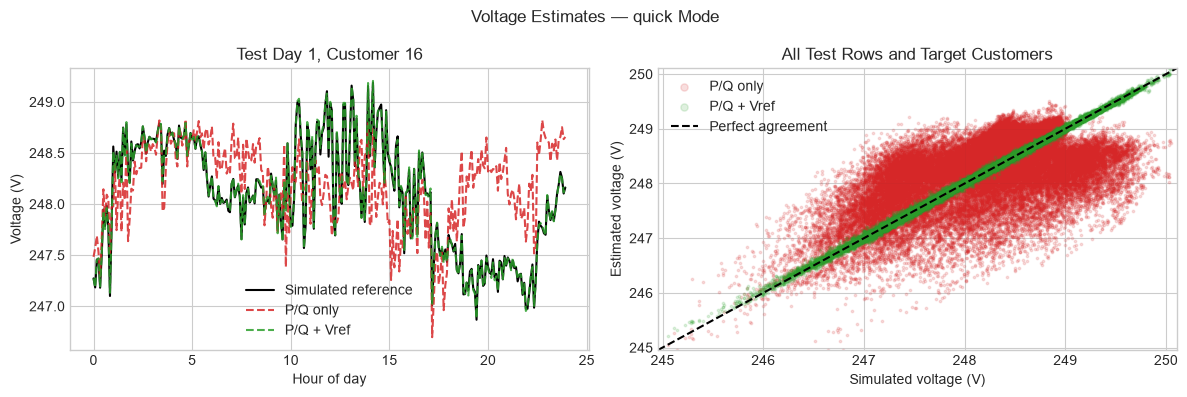

In [23]:
TEST_DAY_TO_PLOT = 1
CUSTOMER_TO_PLOT = 16

test_days = len(Y_TEST) // STEPS_PER_DAY
if not 1 <= TEST_DAY_TO_PLOT <= test_days:
    raise ValueError(f"Choose TEST_DAY_TO_PLOT between 1 and {test_days}.")
if CUSTOMER_TO_PLOT not in TARGET_CUSTOMERS:
    raise ValueError("Choose a target customer, not a reference customer.")

test_start = (TEST_DAY_TO_PLOT - 1) * STEPS_PER_DAY
test_end = test_start + STEPS_PER_DAY
target_position = int(np.flatnonzero(TARGET_CUSTOMERS == CUSTOMER_TO_PLOT)[0])
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60
limits = [
    min(float(Y_TEST.min()), float(test_predictions["PQ_only"].min()),
        float(test_predictions["PQ_plus_Vref"].min())),
    max(float(Y_TEST.max()), float(test_predictions["PQ_only"].max()),
        float(test_predictions["PQ_plus_Vref"].max())),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hours, Y_TEST[test_start:test_end, target_position],
             color="black", label="Simulated reference")
for model_name, colour in [("PQ_only", "tab:red"), ("PQ_plus_Vref", "tab:green")]:
    axes[0].plot(hours, test_predictions[model_name][test_start:test_end, target_position],
                 color=colour, label=MODEL_LABELS[model_name], linestyle="--", alpha=0.85)
    axes[1].scatter(Y_TEST.ravel(), test_predictions[model_name].ravel(),
                    color=colour, s=3, alpha=0.15, label=MODEL_LABELS[model_name])
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Test Day {TEST_DAY_TO_PLOT}, Customer {CUSTOMER_TO_PLOT}")
axes[0].legend()

axes[1].plot(limits, limits, "k--", label="Perfect agreement")
axes[1].set_xlim(limits)
axes[1].set_ylim(limits)
axes[1].set_xlabel("Simulated voltage (V)")
axes[1].set_ylabel("Estimated voltage (V)")
axes[1].set_title("All Test Rows and Target Customers")
axes[1].legend(markerscale=3)
fig.suptitle(f"Voltage Estimates — {RUN_MODE} Mode")
plt.tight_layout()
plt.show()


#### 2.6.3 Compare voltage errors across customers

Compare each target customer's RMSE over the test period. Bars remain in customer order to relate them to Figure 1; the table lists the five largest **P/Q-only** errors and the corresponding errors after adding Vref. The saved CSV contains all 28 target customers.

A higher bar means a larger **prediction error**, not necessarily a higher voltage. The difference **P/Q-only RMSE − P/Q + Vref RMSE** is positive when Vref reduces the error and negative when it increases the error. Reference customers are excluded from both sets of bars.


,Customer,P/Q only RMSE (V),P/Q + Vref RMSE (V),RMSE reduction (V)
16,20,0.686542,0.047104,0.639438
25,29,0.684148,0.036613,0.647534
13,17,0.681792,0.033545,0.648247
22,26,0.681551,0.037850,0.643700
19,23,0.681157,0.035586,0.645571


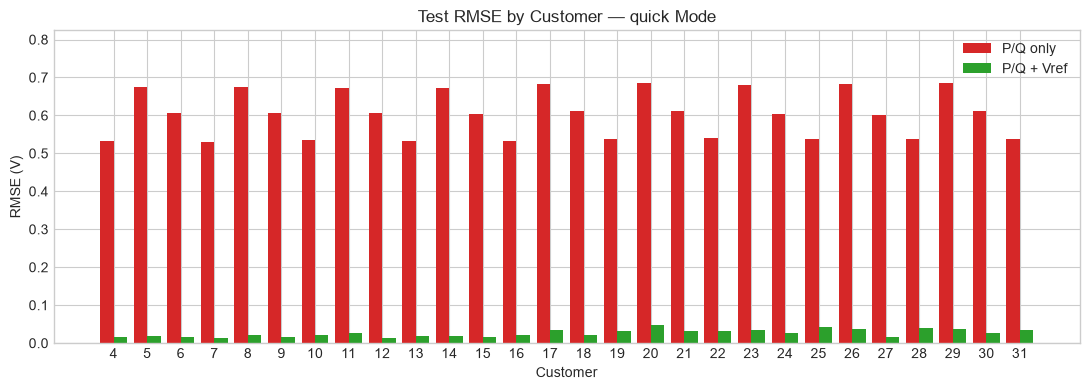

In [24]:
customer_rmse = pd.DataFrame({
    "Customer": TARGET_CUSTOMERS,
    "P/Q only RMSE (V)": np.sqrt(np.mean(test_errors["PQ_only"] ** 2, axis=0)),
    "P/Q + Vref RMSE (V)": np.sqrt(np.mean(test_errors["PQ_plus_Vref"] ** 2, axis=0)),
})
customer_rmse["RMSE reduction (V)"] = customer_rmse["P/Q only RMSE (V)"] - customer_rmse["P/Q + Vref RMSE (V)"]
customer_rmse.to_csv(RESULTS_DIRECTORY / "MV_keras_per_customer_results.csv", index=False)
display(customer_rmse.sort_values("P/Q only RMSE (V)", ascending=False).head(5).round(6))

fig, axis = plt.subplots(figsize=(11, 4))
positions = np.arange(len(TARGET_CUSTOMERS))
axis.bar(positions - 0.2, customer_rmse["P/Q only RMSE (V)"], width=0.4, color="tab:red", label="P/Q only")
axis.bar(positions + 0.2, customer_rmse["P/Q + Vref RMSE (V)"], width=0.4, color="tab:green", label="P/Q + Vref")
axis.set_xticks(positions, TARGET_CUSTOMERS)
axis.set_xlabel("Customer")
axis.set_ylabel("RMSE (V)")
axis.set_title(f"Test RMSE by Customer — {RUN_MODE} Mode")
# Leave space above the bars so the legend does not cover any values.
largest_rmse = max(customer_rmse["P/Q only RMSE (V)"].max(),
                   customer_rmse["P/Q + Vref RMSE (V)"].max())
axis.set_ylim(0, max(float(largest_rmse) * 1.2, 0.01))
axis.legend()
plt.tight_layout()
plt.show()


#### 2.6.4 Inspect the customer with the highest error

Inspect the highest-RMSE **P/Q-only** customer over the full test period. Use this same customer for both models. The upper panel compares voltage curves; the lower panel shows the **residual** (estimate − reference).

Look for persistent positive/negative errors or short spikes. Each model's printed mean signed error helps identify a tendency to overestimate or underestimate. These plots locate errors but do not establish their physical cause.

The final lines report the overall RMSE reduction after adding Vref and the number of target customers whose RMSE decreases. A positive percentage means improvement; a negative percentage means a larger error. The percentage is undefined if the P/Q-only RMSE is zero. Results describe this simulated feeder, reference set and training budget, not a guaranteed accuracy on other feeders or with missing/noisy references.

The workflow is complete: **prepare data → validate shared settings → compare seeds → train final models → assess test voltages**. Report the training mode alongside the errors.


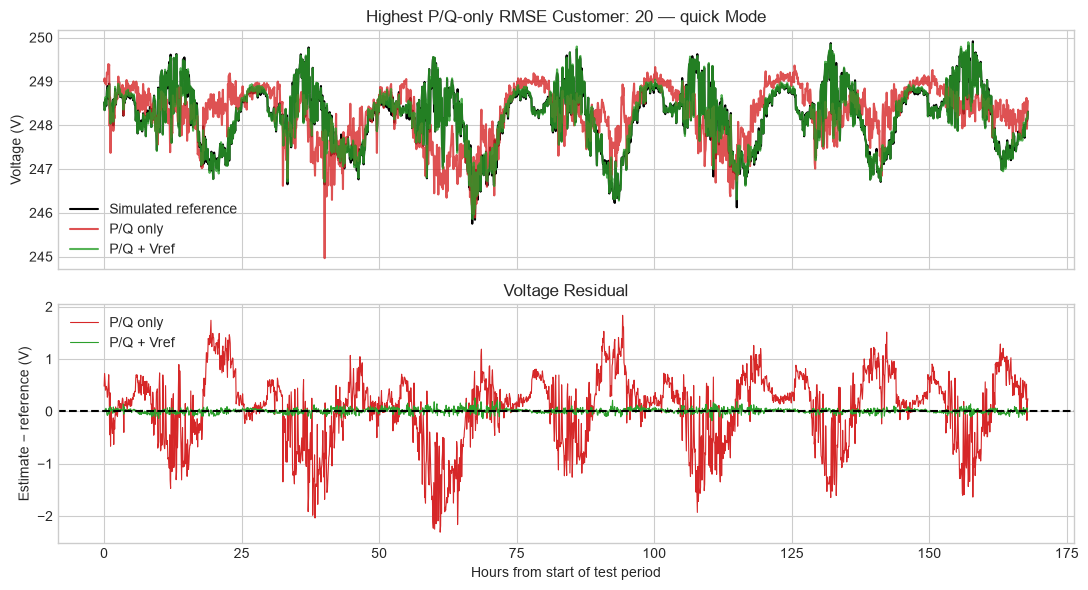

Customer: 20
P/Q only RMSE: 0.686541 V
P/Q only mean signed error: +0.048008 V
P/Q + Vref RMSE: 0.047104 V
P/Q + Vref mean signed error: +0.009427 V
Overall RMSE reduction after adding Vref: 95.43%
Customers with lower RMSE: 28/28


In [25]:
# Use the P/Q-only model to select one customer for both comparisons.
worst_position = int(np.argmax(customer_rmse["P/Q only RMSE (V)"].to_numpy()))
worst_customer = int(TARGET_CUSTOMERS[worst_position])
test_hours = np.arange(len(Y_TEST)) * MINUTES_PER_STEP / 60

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(test_hours, Y_TEST[:, worst_position], color="black", label="Simulated reference")
for model_name, colour in [("PQ_only", "tab:red"), ("PQ_plus_Vref", "tab:green")]:
    axes[0].plot(test_hours, test_predictions[model_name][:, worst_position],
                 color=colour, label=MODEL_LABELS[model_name], alpha=0.8)
    axes[1].plot(test_hours, test_errors[model_name][:, worst_position],
                 color=colour, label=MODEL_LABELS[model_name], linewidth=0.8)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Highest P/Q-only RMSE Customer: {worst_customer} — {RUN_MODE} Mode")
axes[0].legend()

axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Hours from start of test period")
axes[1].set_ylabel("Estimate − reference (V)")
axes[1].set_title("Voltage Residual")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Customer: {worst_customer}")
for model_name in MODEL_NAMES:
    customer_error = test_errors[model_name][:, worst_position]
    print(f"{MODEL_LABELS[model_name]} RMSE: {np.sqrt(np.mean(customer_error ** 2)):.6f} V")
    print(f"{MODEL_LABELS[model_name]} mean signed error: {customer_error.mean():+.6f} V")

pq_rmse = float(test_metrics.loc[test_metrics["Model"] == "P/Q only", "RMSE (V)"].iloc[0])
vref_rmse = float(test_metrics.loc[test_metrics["Model"] == "P/Q + Vref", "RMSE (V)"].iloc[0])
rmse_reduction_percent = 100 * (pq_rmse - vref_rmse) / pq_rmse if pq_rmse > 0 else np.nan
customers_improved = int((customer_rmse["RMSE reduction (V)"] > 0).sum())
print(f"Overall RMSE reduction after adding Vref: {rmse_reduction_percent:.2f}%")
print(f"Customers with lower RMSE: {customers_improved}/{len(TARGET_CUSTOMERS)}")


## 3. Exercises

Read both exercises before starting. Use the relevant code from **2. Tutorial** in **4. Exercise Workspace**. Complete the tasks in order and show your results using code, tables and plots; no written explanations are required.

Both exercises use the same **simulated P/Q and voltage data** as the tutorial. The aim is to practise training neural networks with and without Vref to estimate the same target customers' voltages. Keep the reference customers fixed and use **relu** instead of the tutorial's tanh activation.

<font color='red'>**<u>Note</u>:**</font> Use only training-data folds to choose network settings and seeds. Use the test data only in **E2.3–E2.4**, after these choices are fixed. This is a classroom reuse of the tutorial's test set, not a new independent test. Do not retune the models using their test results.


### **Exercise 1: Comparing Networks With and Without Reference Voltage**

Prepare the two input sets, then compare two hidden-neuron counts using **relu**. For every case, use **three blocked folds**, with scalers fitted only on the training rows of each fold, as in **2.4.3**.

| Setting | Starting value |
|---|---|
| Reference customers | C1, C2 and C3 |
| Target customers | C4–C31, for both models |
| Hidden neurons | 93 and 155 |
| Hidden-layer activation | `relu` |
| Learning rate | `1e-3` |
| L2 strength (`weight_decay`) | `1e-5` |
| Batch size | 72 |
| Epochs | 40 |
| Random seed | 42 |

Keep the reference customers, activation, learning rate, L2 strength, batch size, epochs and seed unchanged throughout Exercise 1. The **40-epoch** budget is a short classroom run, separate from `RUN_MODE`; it is not the tutorial's full training budget.


**E1.1:** Prepare a dictionary containing the **P/Q-only** and **P/Q + Vref** training-input arrays, and one common target array. Store them as `e1_model_inputs` and `e1_targets`. Display the array shapes and the reference and target customer numbers.

**E1.2:** Train and validate both models using **93 hidden neurons**, then repeat with **155 hidden neurons**. Use relu and the fixed settings above. Store the two-configuration validation table as `e1_results`.

**E1.3:** Display each configuration's mean validation RMSE and standard deviation for both models, together with its joint score. Sort by the joint score and store the lowest-scoring configuration as **`e1_best_config`**. Display the selected configuration.

> - Adapt **2.3.6-2.3.7** to prepare inputs and exclude reference customers from the targets.
> - Reuse `run_grid_search()` and the selection code in **2.5.3**.

Two configurations, two models and three folds require **12 training runs**. Do not rerun training just to display the table.


### **Exercise 2: Training and Testing the Voltage Estimators**

Use **`e1_best_config`** from Exercise 1 to complete the training and test procedure. Build **two new models** for the final training runs; do not reuse models already trained on one fold or the tutorial's `FINAL_MODELS`.

Use the following conditions:

- **Network and training settings:** the selected Exercise 1 configuration, including **40 epochs**.
- **Seeds to compare:** **0, 1 and 2**, using the same **three blocked folds**.
- **Final training data:** all rows of `e1_model_inputs` and `e1_targets`.
- **Test inputs:** `PQ_mv_te`, adding only the reference columns of `V_mv_te` for the Vref model.
- **Test target voltages:** the remaining C4–C31 columns of `V_mv_te`, for both models.


**E2.1:** Compare seeds **0, 1 and 2** on the same three blocked folds. Display each seed's two model-specific mean validation RMSE values and joint score. Store the seed with the lowest joint score as **`e2_selected_seed`**.

**E2.2:** Fit new scalers on all exercise training rows and train **two new final models** with the selected configuration and seed. Display the number of inputs, outputs and completed epochs for each model.

**E2.3:** Use test P/Q and the permitted test reference voltages to estimate the **same C4-C31 target voltages**. Display RMSE and MAE for both models, then a table of RMSE by target customer. Do not fit any scaler on test data.

**E2.4:** Find the customer with the highest **P/Q-only test RMSE**. Display its customer number and the RMSE of both models. Plot its simulated voltage and both estimates over the whole test period, followed by a second plot of both residuals (**estimate - simulated reference**).

> - Reuse **2.5.4-2.5.5** for seed selection and final training, using separate `e2_` variables rather than the tutorial's trained models.
> - Reuse **2.6.1** for predictions and errors, **2.6.3** for the customer table, and **2.6.4** for the voltage and error plots. Keep the reference inputs and target outputs separate.

Exercise 2 requires **18 seed-validation fits and 2 final fits**. Both exercises together require **32 training runs**.


## 4. Exercise Workspace

Complete **E1.1–E1.3**, then **E2.1–E2.4**. Add the relevant tutorial code below each task label and display the requested results. The comments are starting points, not completed answers.

In a fresh kernel, run **2.2–2.4** first to load the data and define the functions. You do not need to run **2.5–2.6** again. Use `e1_` and `e2_` variable names to keep your exercise work separate from the tutorial's results.


### Exercise 1: Comparing Networks With and Without Reference Voltage


In [ ]:
# E1.1 — Prepare two training-input sets with the same targets.
e1_reference_customers = [1, 2, 3]
e1_reference_indices = np.array(e1_reference_customers) - 1

# TODO: create e1_target_indices by excluding the references from range(C).
# Create e1_model_inputs with keys "PQ_only" and "PQ_plus_Vref".
# Use PQ_mv_tr and only the reference columns of V_mv_tr as inputs.
# Create e1_targets from the remaining voltage columns.
# Display the input/target shapes and reference/target customer numbers.


In [ ]:
# E1.2 — Compare two hidden-neuron counts using relu.
e1_epochs = 40
e1_seed = 42
e1_k = 3
e1_search_space = {
    "hidden_neurons": [93, 155],
    "activation": ["relu"],
    "lr": [1e-3],
    "weight_decay": [1e-5],
    "batch_size": [72],
    "epochs": [e1_epochs],
}

# TODO: call run_grid_search() with e1_model_inputs, e1_targets,
# e1_search_space, e1_k and e1_seed. Store the table as e1_results.


In [ ]:
# E1.3 — Display the comparison and select the shared configuration.
# TODO: display hidden_neurons, activation, epochs,
# PQ_only_RMSE_kfold, PQ_only_RMSE_std, PQ_plus_Vref_RMSE_kfold,
# PQ_plus_Vref_RMSE_std and joint_RMSE_kfold, lowest joint score first.
# Use the first row to create and display e1_best_config, as in 2.5.3.
# Include hidden_neurons, activation, lr, weight_decay, batch_size and epochs.


### Exercise 2: Training and Testing the Voltage Estimators


In [ ]:
# E2.1 — Compare seeds without using test targets.
e2_seeds = [0, 1, 2]

# TODO: call run_seed_search() with the exercise inputs, targets,
# e1_best_config, e2_seeds and k=3. Store e2_seed_results.
# Display the model-specific mean RMSE values and joint score.
# Store the first row's seed as the integer e2_selected_seed.


In [ ]:
# E2.2 — Train two new models on all exercise training rows.
# TODO: fit e2_output_scaler on e1_targets.
# For each input set, fit a new input scaler on that training array.
# Build and train a new model using e1_best_config and e2_selected_seed.
# Store the models in e2_models and the input scalers in e2_input_scalers.
# Display each model's input/output sizes and completed epochs.


In [ ]:
# E2.3 — Estimate test voltages in volts.
# TODO: assemble e2_test_inputs from test P/Q and permitted Vref columns.
# Create e2_test_targets using the same e1_target_indices.
# Apply fitted input scalers, then call predict_unscaled().
# Store e2_predictions and e2_errors for both models.
# Display overall RMSE and MAE, and RMSE for every target customer.


In [ ]:
# E2.4 — Inspect the customer with the highest P/Q-only test RMSE.
# TODO: find its position in the exercise target array and customer number.
# Display its RMSE for both models.
# Adapt Section 2.6.4 using your exercise predictions and errors.
# Plot simulated voltage and both estimates over the complete test period.
# In a second panel, plot both residuals with a horizontal zero-error line.
